## A function for extracting data from logs

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import re


BASELINE_PATH = './logs/baseline16/'
ABLATION_PATH = './logs/ablation/'
ITERS_PER_VAL = 2000
METRICS = ['iou', 'acc', 'dice', 'elapsed', 'iter']

def extract_building_metrics(log_path):
    metrics = {key: [] for key in METRICS}
    start_time, timestamp = None, None
    date_pattern = re.compile(r'(\d{2}/\d{2}) (\d{2}:\d{2}:\d{2}) .*')
    with open(log_path, 'r') as f:
        for line in f:
            
            if match := date_pattern.match(line):
                date_str, time_str = match.group(1,2)
                timestamp = datetime.strptime(f"{datetime.now().year}/{date_str} {time_str}",
                                            "%Y/%m/%d %H:%M:%S")
            
            if not start_time and timestamp:
                start_time = timestamp
            if line.startswith('|  building  | '):
                parts = line.split('|')
                metrics['iou'].append(float(parts[2].strip()))
                metrics['acc'].append(float(parts[3].strip()))
                metrics['dice'].append(float(parts[4].strip()))
                metrics['elapsed'].append((timestamp - start_time).total_seconds() / (60.0 * 60))  # hours
                metrics['iter'].append(len(metrics['iou']) * ITERS_PER_VAL)

    return metrics




## A function for accumulating data from different runs

In [3]:
def accumulate_building_metrics(path):
    all_metrics = {key : [] for key in METRICS}
    for name in os.listdir(path):
        if not name.endswith('.log'):
            continue

        log_path = os.path.join(path, name)
        metrics = extract_building_metrics(log_path)
        for key in all_metrics:
            all_metrics[key].append(metrics[key])
    
    # acumulate
    return { key : np.array(val) for key, val in all_metrics.items() }

ablation_metrics = accumulate_building_metrics(ABLATION_PATH)
ablation_metrics


{'iou': array([[0.000e+00, 4.940e+00, 4.800e-01, 1.716e+01, 3.005e+01, 3.341e+01,
         3.748e+01, 4.716e+01, 4.385e+01, 5.258e+01, 5.474e+01, 5.688e+01,
         5.456e+01, 5.755e+01, 5.721e+01, 6.101e+01, 6.133e+01, 6.156e+01,
         6.257e+01, 6.241e+01],
        [2.300e-01, 1.100e-01, 3.384e+01, 3.476e+01, 3.804e+01, 4.678e+01,
         4.829e+01, 3.530e+01, 4.736e+01, 5.519e+01, 5.346e+01, 5.608e+01,
         5.472e+01, 5.947e+01, 5.828e+01, 5.668e+01, 5.889e+01, 6.144e+01,
         6.035e+01, 6.232e+01],
        [4.200e-01, 1.000e-02, 7.040e+00, 1.518e+01, 3.151e+01, 3.765e+01,
         4.390e+01, 4.770e+01, 5.076e+01, 5.402e+01, 5.591e+01, 5.523e+01,
         5.622e+01, 5.858e+01, 6.050e+01, 5.954e+01, 6.162e+01, 6.205e+01,
         6.221e+01, 6.237e+01]]),
 'acc': array([[0.000e+00, 4.990e+00, 4.800e-01, 1.854e+01, 3.311e+01, 3.648e+01,
         4.127e+01, 5.505e+01, 4.806e+01, 7.220e+01, 6.490e+01, 7.301e+01,
         6.334e+01, 6.724e+01, 6.533e+01, 7.563e+01, 7.681e+01,

## Averaging runs on the same time axis with interpolation

In [4]:
def aggragate_over_time(metrics, num_points=100):
    # Find the  maximum elapsed time across all runs
    l = metrics['elapsed'].shape[1]
    max_t = np.average(metrics['elapsed'][:, l - 1])

    common_t = np.linspace(0, max_t, num_points)
    means, stds = {}, {}
    for key in ['iou', 'acc', 'dice']:
        interpolated = []
        for run_t, run_y in zip(metrics['elapsed'], metrics[key]):
            # interpolate onto the common timeline
            y_interp = np.interp(common_t, run_t, run_y)
            interpolated.append(y_interp)
        interpolated = np.stack(interpolated)
        means[key] = interpolated.mean(axis=0)
        stds[key] = interpolated.std(axis=0)

    return common_t, means, stds


aggragate_over_time(ablation_metrics)[1]

{'iou': array([ 0.21666667,  0.21666667,  0.21666667,  0.21666667,  0.21666667,
         0.21666667,  0.5097598 ,  0.80723494,  1.10471007,  1.4021852 ,
         1.74645563,  4.19076452,  6.63661968,  9.08247483, 11.52832999,
        13.94570357, 15.68447077, 17.42323797, 19.16200518, 20.90077238,
        22.69025828, 24.88357307, 27.07688786, 29.27020265, 31.46351745,
        33.43319661, 34.66330093, 35.89340526, 37.12350958, 38.3536139 ,
        39.49509619, 40.29325438, 41.09141258, 41.88957077, 42.68772896,
        43.30974689, 43.34793048, 43.38611407, 43.42429766, 43.46248124,
        43.61725573, 44.41246931, 45.20768289, 46.00289647, 46.79811005,
        47.88166483, 49.21848741, 50.55530998, 51.89213256, 53.22895513,
        54.03110509, 54.18830451, 54.34550393, 54.50270336, 54.65990278,
        54.83551322, 55.10983905, 55.38416488, 55.65849071, 55.93281654,
        55.96452922, 55.78351839, 55.60250757, 55.42149674, 55.24048592,
        55.58667694, 56.26716877, 56.9476606

## Plot 

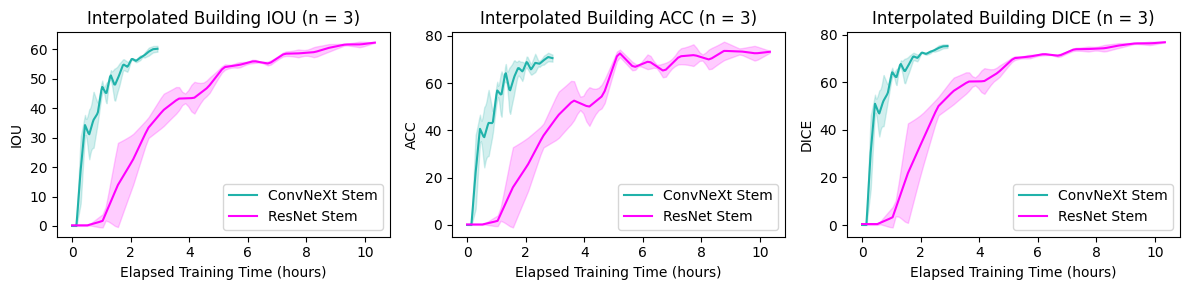

In [5]:
(fig, axes) = plt.subplots(1,3, figsize=(12, 3))
baseline_acc = accumulate_building_metrics(BASELINE_PATH)
abl_acc = accumulate_building_metrics(ABLATION_PATH)
for (name, ax) in zip(['iou', 'acc', 'dice'], axes):
    for (metrics, label, color) in [
        (baseline_acc, 'ConvNeXt Stem', 'lightseagreen'),
        (abl_acc, 'ResNet Stem', 'fuchsia')
    ]:
        t, means, stds = aggragate_over_time(metrics)
        ax.plot(t, means[name], label=label, color=color)
        ax.fill_between(t, means[name] - stds[name], means[name] + stds[name], color=color, alpha=0.2)
    ax.set_title(f'Interpolated Building {name.upper()} (n = {metrics[name].shape[0]})')
    ax.set_xlabel('Elapsed Training Time (hours)')
    ax.set_ylabel(name.upper())
    ax.legend()
    fig.tight_layout()


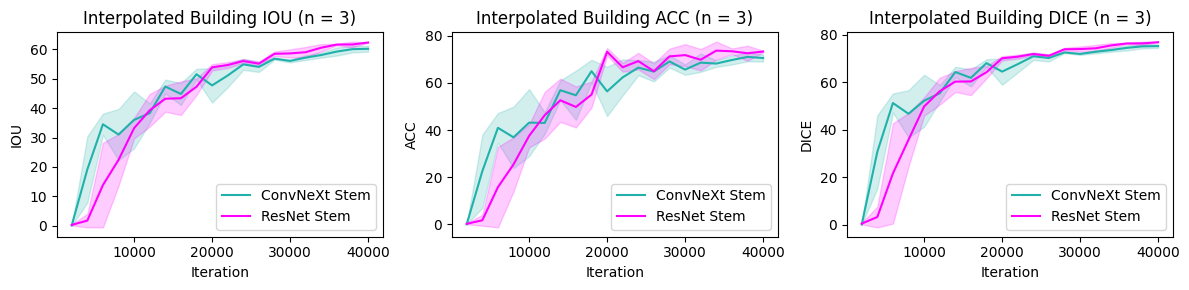

In [6]:
(fig, axes) = plt.subplots(1, 3, figsize=(12, 3))
for (name, ax) in zip(['iou', 'acc', 'dice'], axes):
    for (metrics, label, color) in [
        (baseline_acc, 'ConvNeXt Stem', 'lightseagreen'),
        (abl_acc, 'ResNet Stem', 'fuchsia')
    ]:
        means = np.mean(metrics[name], axis=0)
        stds = np.std(metrics[name], axis=0)
        iters = metrics['iter'].mean(axis=0)

        ax.plot(iters, means, label=label, color=color)
        ax.fill_between(iters, means - stds, means + stds, color=color, alpha=0.2)
    ax.set_title(f'Interpolated Building {name.upper()} (n = {metrics[name].shape[0]})')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(name.upper())
    ax.legend(loc='lower right')
    fig.tight_layout()

In [7]:
for (name, acc) in (('baseline', baseline_acc), ('ablation', abl_acc)):
    el = acc['elapsed']
    t = el[:,el.shape[1]-1] - el[:,0]
    t_avg = np.average(t, axis=0)
    t_std = np.std(t, axis=0)
    print(f'{name} hours: {t_avg} +/- {t_std}')

baseline hours: 2.765 +/- 0.0003928371006591498
ablation hours: 9.808518518518516 +/- 0.01716887396412953


# Calculate results from testing runs

In [11]:
labels = ['IoU', 'Dice', 'Acc']
ablation_metrics = np.array([
    [63.17, 74.51, 77.43], #ablation 1
    [62.94, 73.44, 77.25], # ablation 2
   #  [62.37, 73.51, 76.82], # ablation 3 ..
    [63.23, 73.6, 77.47] # ablation 4
])

baseline_metrics = np.array([
    #  [59.57, 70.7, 74.66],
    #  [59.77, 69.53, 74.82],
    # [61.63, 72.67, 76.26]
    [60.43, 70.99, 75.33], # baseline 3
    [60.62, 69.69, 75.48], # baseline 4
    [62.32, 72.56, 76.78 ] # baseline 5
])

for (set_name, metrics) in (('ablation', ablation_metrics), ('baseline', baseline_metrics)):
    for (label, avg, std) in zip(labels, np.average(metrics, axis=0), np.std(metrics, axis=0)):
        print(f'{set_name} {label} avg: {avg} std: {std}')


ablation IoU avg: 63.11333333333334 std: 0.12498888839501816
ablation Dice avg: 73.85 std: 0.47123950032512185
ablation Acc avg: 77.38333333333334 std: 0.0956846672960496
baseline IoU avg: 61.123333333333335 std: 0.8497189077702245
baseline Dice avg: 71.08 std: 1.1733996193397505
baseline Acc avg: 75.86333333333333 std: 0.6510674994874872


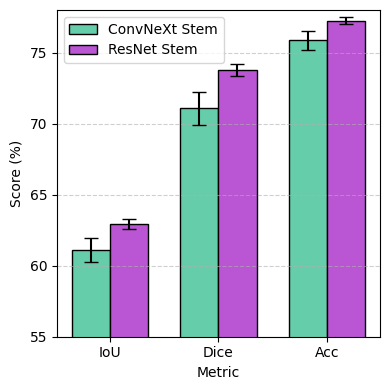

In [9]:
# Compute mean and std
ablation_avg = np.mean(ablation_metrics, axis=0)
ablation_std = np.std(ablation_metrics, axis=0)
baseline_avg = np.mean(baseline_metrics, axis=0)
baseline_std = np.std(baseline_metrics, axis=0)

# Plot setup
x = np.arange(len(labels))  # label locations
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(4, 4))

# Bars
ax.bar(x - width/2, baseline_avg, width, yerr=baseline_std, capsize=5,
       label='ConvNeXt Stem', color='mediumaquamarine', edgecolor='black')
ax.bar(x + width/2, ablation_avg, width, yerr=ablation_std, capsize=5,
       label='ResNet Stem', color='mediumorchid', edgecolor='black')

# Formatting
ax.set_ylabel('Score (%)')
ax.set_xlabel('Metric')
ax.set_ylim(55, 78)
#ax.set_title('Baseline vs Ablation Performance')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
